# 01 - EDA: Brisbane Water Quality Buoy

Dataset characterization, data-quality verification, and distribution analysis
for the Brisbane buoy water-quality dataset (Kaggle: `downshift/water-quality-monitoring-dataset`,
file `brisbane_water_quality.csv`). This notebook exists to answer, with evidence, the
questions the pipeline design depends on: is the timestamp really monotonic, are the
`[quality]` columns real, what's the actual sampling interval, and how much data do we
lose to missingness before modeling even starts.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_raw_data
from src.validation import validate_raw_data
from src.cleaning import clean_pipeline
from src.smoothing import apply_smoothing
from src.feature_engineering import build_feature_matrix, correlation_matrix
from src.config import SENSOR_COLUMNS, PRIMARY_TARGET

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 30)
plt.rcParams['figure.dpi'] = 110

## 1. Load raw data

In [2]:
raw = load_raw_data()
print(f"Shape: {raw.shape}")
raw.head()

2026-07-18 19:39:12,341 | INFO     | src.data_loader | Loading raw CSV from /home/icarus/DO_Predictor/data/raw/brisbane_water_quality.csv


2026-07-18 19:39:12,384 | INFO     | src.data_loader | Dropped pH column(s) ['pH', 'pH [quality]'] - this system is Dissolved-Oxygen-only.


2026-07-18 19:39:12,385 | INFO     | src.data_loader | Loaded 30894 rows, 18 columns.


Shape: (30894, 18)


,Timestamp,Record number,Average Water Speed,Average Water Direction,Chlorophyll,Chlorophyll [quality],Temperature,Temperature [quality],Dissolved Oxygen,Dissolved Oxygen [quality],Dissolved Oxygen (%Saturation),Dissolved Oxygen (%Saturation) [quality],Salinity,Salinity [quality],Specific Conductance,Specific Conductance [quality],Turbidity,Turbidity [quality]
0,2023-08-04 23:00:00,1468,4.834,73.484,1.621,NaN,20.018,NaN,7.472,NaN,101.175,NaN,35.215,NaN,53.262,NaN,2.068,NaN
1,2023-08-04 23:30:00,1469,2.544,106.424,1.959,NaN,19.986,NaN,7.455,NaN,100.884,NaN,35.209,NaN,53.254,NaN,1.994,NaN
2,2023-08-04 23:00:00,1470,1.260,156.755,1.620,NaN,20.001,NaN,7.430,NaN,100.571,NaN,35.207,NaN,53.252,NaN,2.030,NaN
3,2023-08-04 23:30:00,1471,0.760,281.754,1.761,NaN,19.983,NaN,7.419,NaN,100.398,NaN,35.211,NaN,53.257,NaN,1.973,NaN
4,2023-08-04 23:00:00,1472,3.397,244.637,1.635,NaN,19.986,NaN,7.429,NaN,100.538,NaN,35.208,NaN,53.253,NaN,1.944,NaN


In [3]:
raw.dtypes

Timestamp                                   datetime64[us]
Record number                                        int64
Average Water Speed                                float64
Average Water Direction                            float64
Chlorophyll                                        float64
Chlorophyll [quality]                              float64
Temperature                                        float64
Temperature [quality]                              float64
Dissolved Oxygen                                   float64
Dissolved Oxygen [quality]                         float64
Dissolved Oxygen (%Saturation)                     float64
Dissolved Oxygen (%Saturation) [quality]           float64
Salinity                                           float64
Salinity [quality]                                 float64
Specific Conductance                               float64
Specific Conductance [quality]                     float64
Turbidity                                          float

## 2. Dataset characterization table

In [4]:
summary_rows = []
for col in SENSOR_COLUMNS:
    s = raw[col]
    summary_rows.append({
        'column': col,
        'dtype': str(s.dtype),
        'n_missing': int(s.isna().sum()),
        'pct_missing': round(s.isna().mean() * 100, 2),
        'min': s.min(),
        'max': s.max(),
        'mean': round(s.mean(), 3),
        'std': round(s.std(), 3),
    })
characterization = pd.DataFrame(summary_rows)
characterization

,column,dtype,n_missing,pct_missing,min,max,mean,std
0,Average Water Speed,float64,20,0.06,0.000,89.912,16.799,13.169
1,Average Water Direction,float64,1,0.00,0.000,359.994,177.545,103.622
2,Chlorophyll,float64,585,1.89,0.100,43.301,2.782,1.859
3,Temperature,float64,5164,16.72,17.000,32.063,24.415,3.495
4,Dissolved Oxygen,float64,4300,13.92,3.030,9.260,6.815,0.621
5,Dissolved Oxygen (%Saturation),float64,5749,18.61,51.836,134.082,96.641,8.108
6,Salinity,float64,3958,12.81,0.057,36.000,31.003,3.469
7,Specific Conductance,float64,1367,4.42,0.021,54.996,47.927,5.155
8,Turbidity,float64,2000,6.47,0.335,49.869,3.942,4.073


## 3. Raw-data quality report

Runs every integrity check the project relies on: missingness, duplicate timestamps,
whether `Record number` or `Timestamp` is the trustworthy row order, actual sampling
cadence, physically-impossible values, and whether each `[quality]` column carries
real instrument codes.

In [5]:
report = validate_raw_data(raw)
import json
print(json.dumps(report.to_dict(), indent=2, default=str))

2026-07-18 19:39:12,440 | INFO     | src.validation | Validation done: 30894 rows, 280 dup timestamps, 7 quality cols kept, 0 dropped, modal cadence=10.0 min.


2026-07-18 19:39:12,441 | INFO     | src.validation | note: 280 duplicate Timestamp values (different Record numbers, same clock reading) - resolved in cleaning.py.


2026-07-18 19:39:12,441 | INFO     | src.validation | note: 2 backward timestamp jump(s) even under Record-number order.


2026-07-18 19:39:12,441 | INFO     | src.validation | note: Modal sampling cadence is 10 min, not the commonly-cited 30 min. RESAMPLE_FREQ in config.py is set to match.


2026-07-18 19:39:12,442 | INFO     | src.validation | note: 2 gap(s) longer than 1 hour (sensor downtime).


2026-07-18 19:39:12,442 | INFO     | src.validation | note: Quality columns populated with real codes, kept: ['Chlorophyll [quality]', 'Temperature [quality]', 'Dissolved Oxygen [quality]', 'Dissolved Oxygen (%Saturation) [quality]', 'Salinity [quality]', 'Specific Conductance [quality]', 'Turbidity [quality]']


{
  "n_rows": 30894,
  "n_columns": 18,
  "missingness_pct": {
    "Timestamp": 0.0,
    "Record number": 0.0,
    "Average Water Speed": 0.0647,
    "Average Water Direction": 0.0032,
    "Chlorophyll": 1.8936,
    "Chlorophyll [quality]": 2.6154,
    "Temperature": 16.7152,
    "Temperature [quality]": 17.2979,
    "Dissolved Oxygen": 13.9186,
    "Dissolved Oxygen [quality]": 14.6436,
    "Dissolved Oxygen (%Saturation)": 18.6088,
    "Dissolved Oxygen (%Saturation) [quality]": 19.2594,
    "Salinity": 12.8115,
    "Salinity [quality]": 13.5366,
    "Specific Conductance": 4.4248,
    "Specific Conductance [quality]": 5.1499,
    "Turbidity": 6.4737,
    "Turbidity [quality]": 7.1988
  },
  "duplicate_row_count": 265,
  "duplicate_timestamp_count": 280,
  "record_number_is_canonical_order": true,
  "record_number_gap_count": 0,
  "timestamp_monotonic_raw": false,
  "timestamp_monotonic_by_record_order": false,
  "timestamp_backward_jump_count": 2,
  "modal_cadence_minutes": 10.0,
  

### Key findings

- **Timestamp is not reliable as a sort key.** It has 280 duplicate values and 2 backward
  jumps. `Record number` is strictly increasing with zero gaps across all 30,894 rows and
  is used as the canonical row order everywhere downstream.
- **The dataset is commonly described as 30-minute interval data. It isn't** - the modal
  spacing between consecutive records is 10 minutes, with a secondary mode at 30 minutes.
  `config.RESAMPLE_FREQ` is set to `10min` to match reality rather than the description.
- **The `[quality]` columns are real, not empty placeholders.** Every quality column for
  the sensors this project uses (all sensors except Average Water Speed/Direction, which
  have none, and pH, which this project doesn't use - see below) is populated with actual
  instrument codes. Code `1020` dominates (>99% of non-null flags on most columns) and is
  treated as "good"; anything else non-null is treated as suspect and nulled out before
  interpolation in `cleaning.py`.
- **This project is Dissolved-Oxygen-only.** The raw file also contains a `pH` column
  (and paired `pH [quality]`), but `data_loader.py` drops both immediately on load - pH
  never reaches validation, cleaning, feature engineering, or any model below.
- No physically-impossible values were found once compared against generous sensor-specific
  bounds (see `validation.PLAUSIBLE_RANGES`).

## 4. Missingness by column

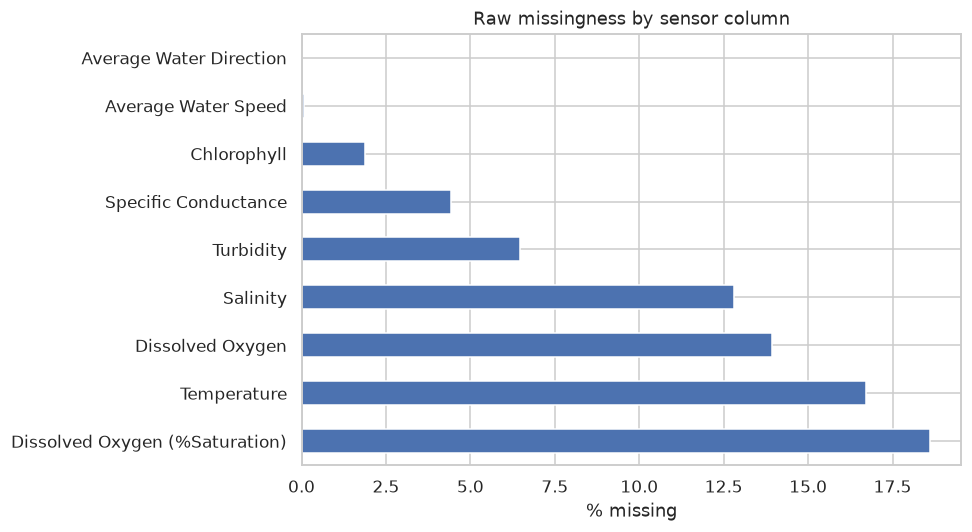

In [6]:
missing_pct = raw[SENSOR_COLUMNS].isna().mean().sort_values(ascending=False) * 100
fig, ax = plt.subplots(figsize=(9, 5))
missing_pct.plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_xlabel('% missing')
ax.set_title('Raw missingness by sensor column')
plt.tight_layout()
plt.savefig('../reports/eda_missingness.png', bbox_inches='tight')
plt.show()

## 5. Quality-column composition

For each populated quality column, what fraction of *non-null* flags are the modal
"good" code (1020) vs something else.

In [7]:
qual_df = pd.DataFrame({
    'quality_column': list(report.quality_good_fraction.keys()),
    'pct_good_of_nonnull': [round(v * 100, 3) for v in report.quality_good_fraction.values()],
})
qual_df

,quality_column,pct_good_of_nonnull
0,Chlorophyll [quality],99.997
1,Temperature [quality],99.828
2,Dissolved Oxygen [quality],99.951
3,Dissolved Oxygen (%Saturation) [quality],99.699
4,Salinity [quality],100.000
5,Specific Conductance [quality],100.000
6,Turbidity [quality],100.000


## 6. Sampling cadence

Time step between consecutive records, ordered by `Record number` (not by sorting
raw `Timestamp`, which would scramble same-timestamp rows).

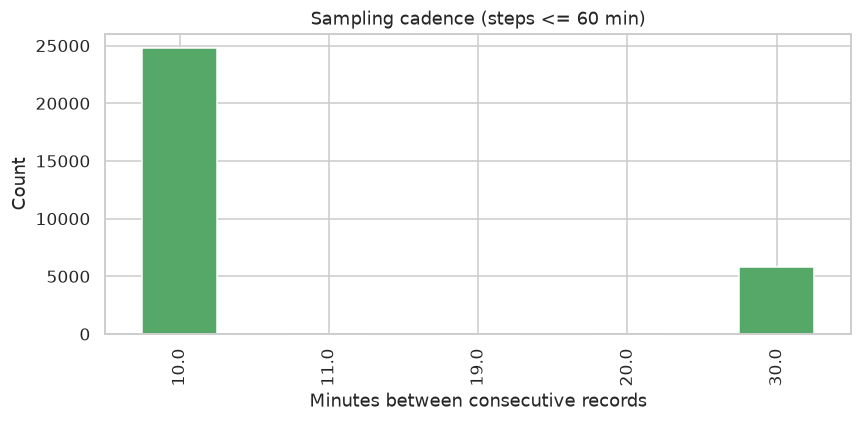

In [8]:
from src.config import RECORD_NUMBER_COL, TIMESTAMP_COL
ordered = raw.sort_values(RECORD_NUMBER_COL)
diffs_min = ordered[TIMESTAMP_COL].diff().dt.total_seconds().dropna() / 60
fig, ax = plt.subplots(figsize=(8, 4))
diffs_min[(diffs_min > 0) & (diffs_min <= 60)].value_counts().sort_index().plot(kind='bar', ax=ax, color='#55A868')
ax.set_xlabel('Minutes between consecutive records')
ax.set_ylabel('Count')
ax.set_title('Sampling cadence (steps <= 60 min)')
plt.tight_layout()
plt.savefig('../reports/eda_cadence.png', bbox_inches='tight')
plt.show()

## 7. Cleaning pipeline effect

Runs the full clean -> resample -> interpolate sequence and compares row counts /
remaining missingness before vs after.

In [9]:
clean_df, clean_report = clean_pipeline(raw, report.quality_columns_kept)
print(f"Raw rows: {len(raw)}  ->  Resampled (10min grid) rows: {len(clean_df)}")
print(json.dumps(clean_report, indent=2, default=str))

2026-07-18 19:39:12,859 | INFO     | src.cleaning | Quality-flag nulling: {'Chlorophyll': 1, 'Temperature': 44, 'Dissolved Oxygen': 13, 'Dissolved Oxygen (%Saturation)': 75, 'Salinity': 0, 'Specific Conductance': 0, 'Turbidity': 0}


2026-07-18 19:39:12,873 | INFO     | src.cleaning | Resampled 30894 raw rows -> 47149 bins at 10min (from 30614 unique timestamps).


2026-07-18 19:39:12,912 | INFO     | src.cleaning | Interpolation filled: {'Average Water Speed': 11688, 'Average Water Direction': 11669, 'Chlorophyll': 11968, 'Temperature': 11972, 'Dissolved Oxygen': 11840, 'Dissolved Oxygen (%Saturation)': 10710, 'Salinity': 9483, 'Specific Conductance': 11777, 'Turbidity': 9420}


2026-07-18 19:39:12,930 | INFO     | src.cleaning | Flagged 435 outlier readings across all sensors (not dropped).


2026-07-18 19:39:12,931 | INFO     | src.cleaning | Cleaning pipeline complete: 47149 rows in final frame.


Raw rows: 30894  ->  Resampled (10min grid) rows: 47149
{
  "quality_nulled_counts": {
    "Chlorophyll": 1,
    "Temperature": 44,
    "Dissolved Oxygen": 13,
    "Dissolved Oxygen (%Saturation)": 75,
    "Salinity": 0,
    "Specific Conductance": 0,
    "Turbidity": 0
  },
  "n_rows_after_resample": 47149,
  "interpolation_filled_counts": {
    "Average Water Speed": 11688,
    "Average Water Direction": 11669,
    "Chlorophyll": 11968,
    "Temperature": 11972,
    "Dissolved Oxygen": 11840,
    "Dissolved Oxygen (%Saturation)": 10710,
    "Salinity": 9483,
    "Specific Conductance": 11777,
    "Turbidity": 9420
  },
  "remaining_na_after_cleaning": {
    "Average Water Speed": 4867,
    "Average Water Direction": 4867,
    "Chlorophyll": 5141,
    "Temperature": 9730,
    "Dissolved Oxygen": 8952,
    "Dissolved Oxygen (%Saturation)": 11576,
    "Salinity": 10961,
    "Specific Conductance": 6106,
    "Turbidity": 9075
  }
}


In [10]:
before_after = pd.DataFrame({
    'raw_pct_missing': raw[SENSOR_COLUMNS].isna().mean() * 100,
    'clean_pct_missing': clean_df[SENSOR_COLUMNS].isna().mean() * 100,
}).round(2)
before_after

,raw_pct_missing,clean_pct_missing
Average Water Speed,0.06,10.32
Average Water Direction,0.00,10.32
Chlorophyll,1.89,10.90
Temperature,16.72,20.64
Dissolved Oxygen,13.92,18.99
Dissolved Oxygen (%Saturation),18.61,24.55
Salinity,12.81,23.25
Specific Conductance,4.42,12.95
Turbidity,6.47,19.25


## 8. Distributions

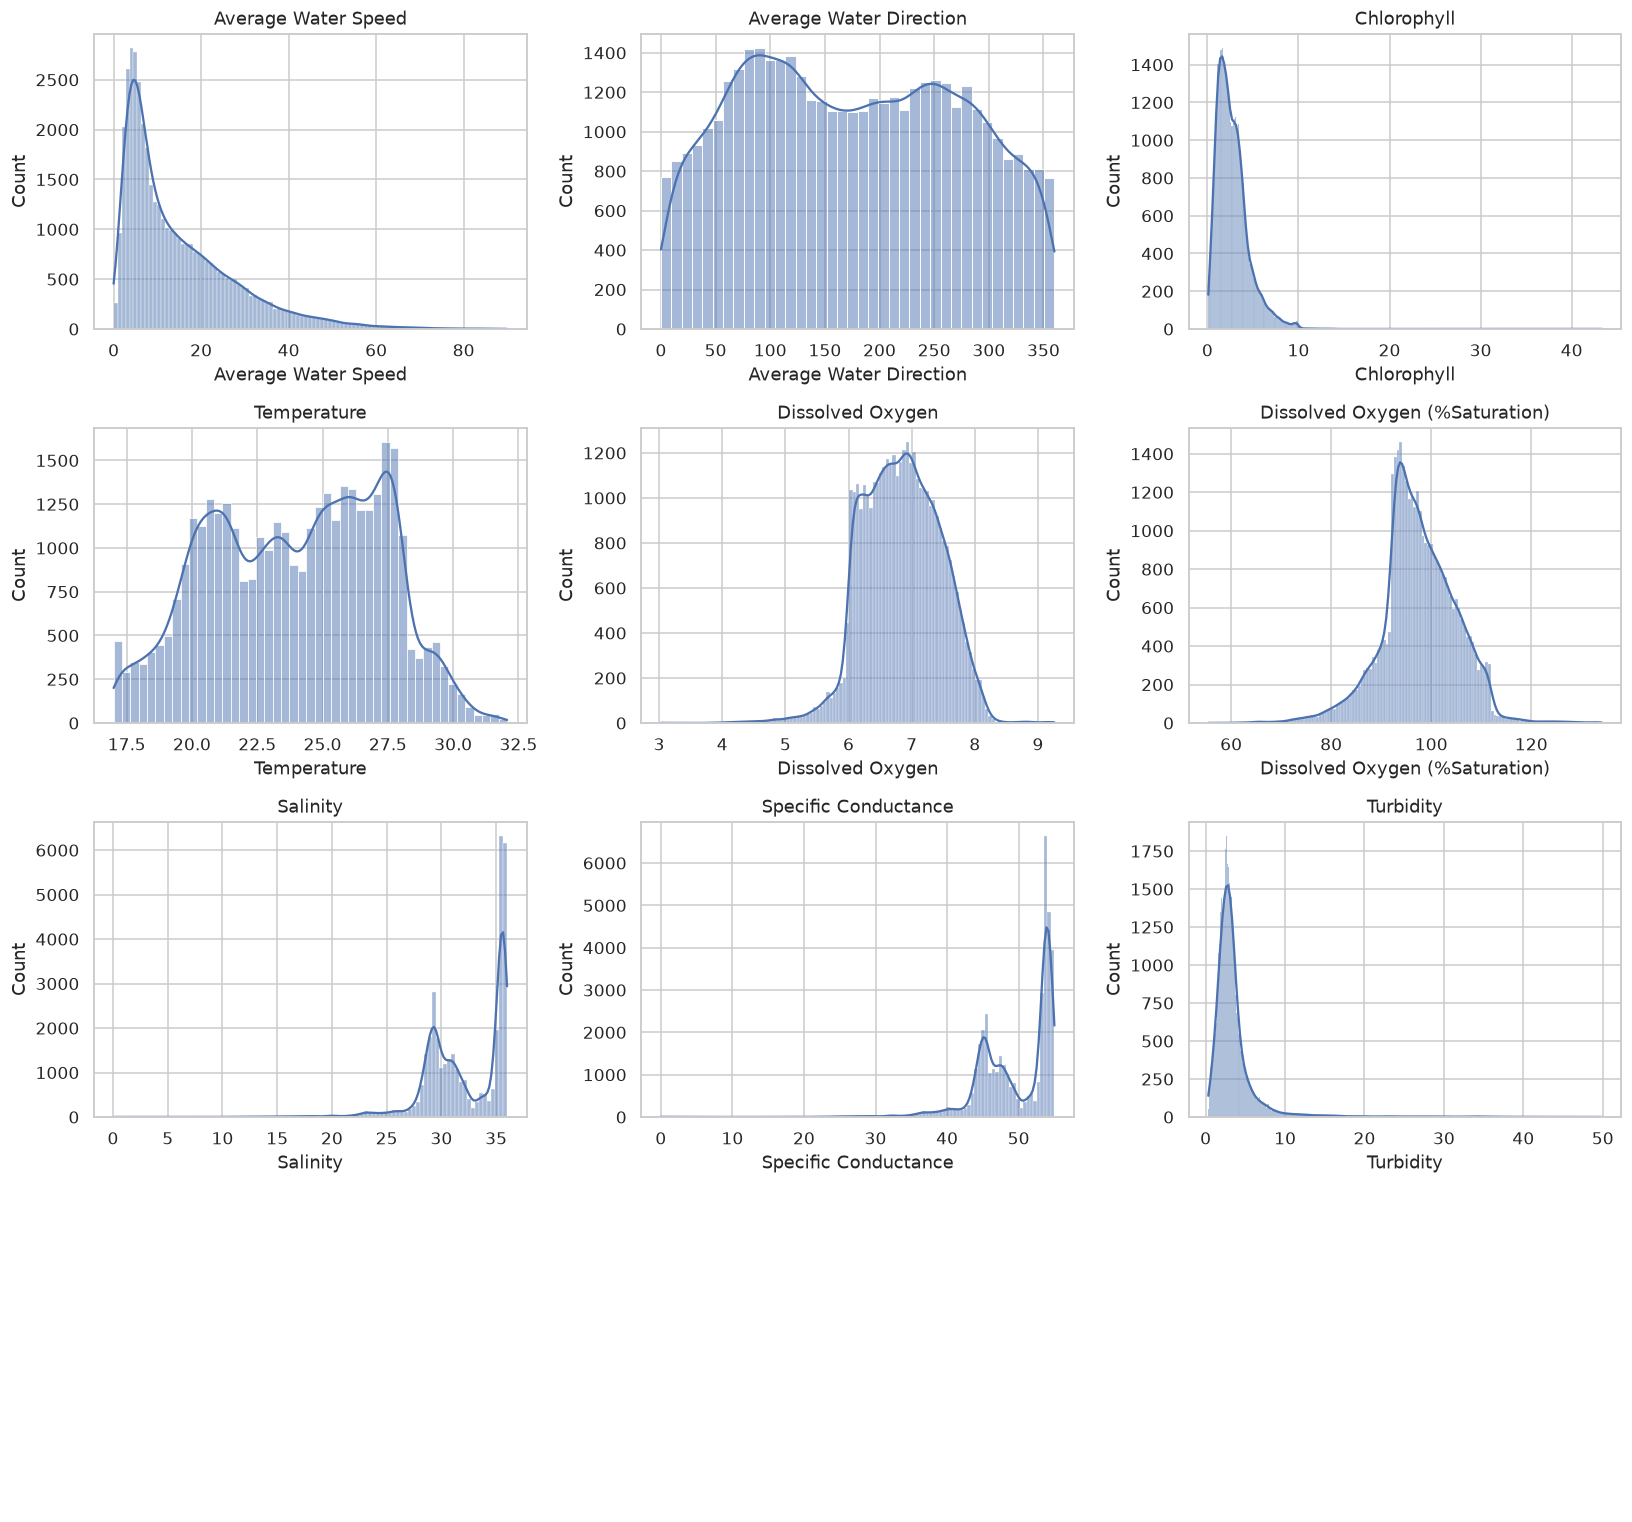

In [11]:
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
for ax, col in zip(axes.flat, SENSOR_COLUMNS):
    sns.histplot(clean_df[col].dropna(), kde=True, ax=ax, color='#4C72B0')
    ax.set_title(col)
for ax in axes.flat[len(SENSOR_COLUMNS):]:
    ax.axis('off')
plt.tight_layout()
plt.savefig('../reports/eda_distributions.png', bbox_inches='tight')
plt.show()

## 9. Correlation heatmap

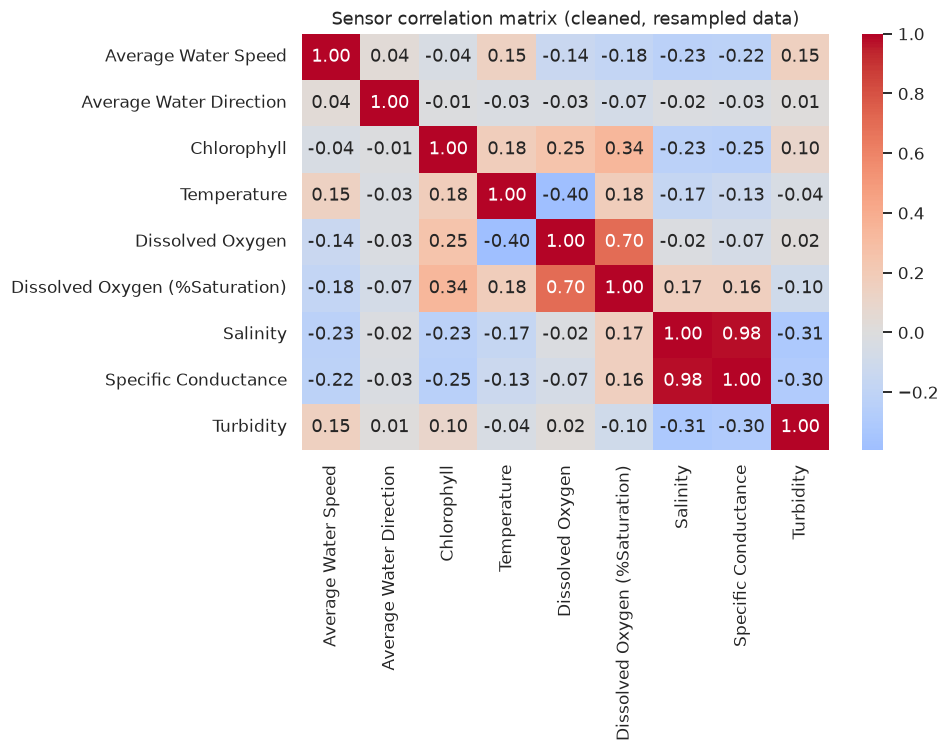

In [12]:
corr = correlation_matrix(clean_df)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Sensor correlation matrix (cleaned, resampled data)')
plt.tight_layout()
plt.savefig('../reports/eda_correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 10. Target time series: Dissolved Oxygen

Full-record view - looking for seasonality, drift, and the sensor-outage gaps
identified above.

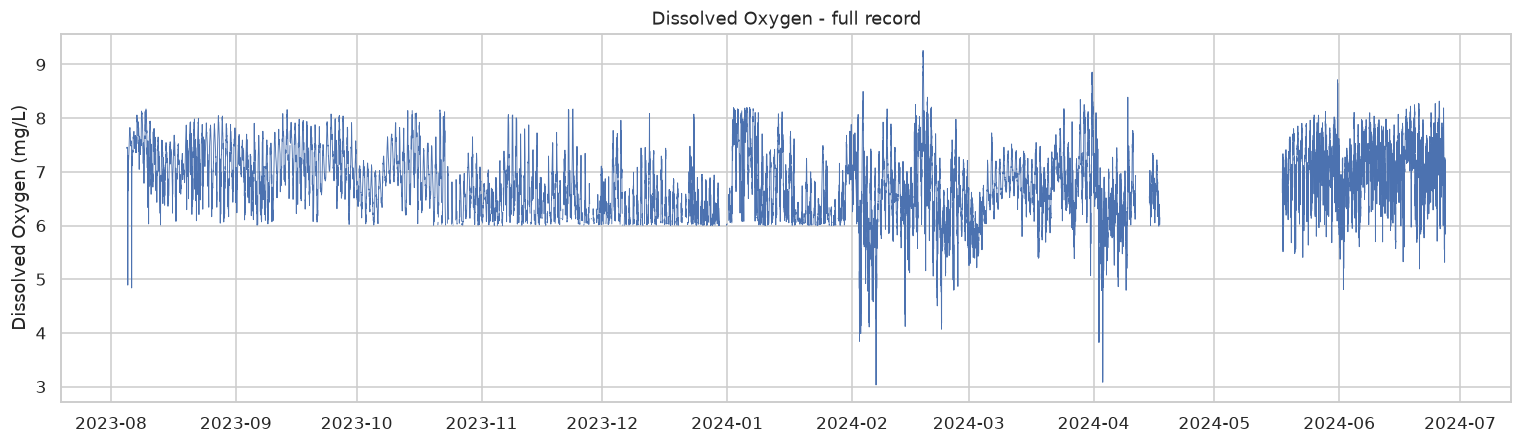

In [13]:
fig, ax = plt.subplots(figsize=(14, 4.2))
ax.plot(clean_df['Timestamp'], clean_df[PRIMARY_TARGET], linewidth=0.6, color='#4C72B0')
ax.set_ylabel('Dissolved Oxygen (mg/L)')
ax.set_title('Dissolved Oxygen - full record')
plt.tight_layout()
plt.savefig('../reports/eda_target_timeseries.png', bbox_inches='tight')
plt.show()

## Summary

| Check | Result |
|---|---|
| Rows (raw) | 30,894 |
| Canonical row order | `Record number` (strictly increasing, zero gaps) |
| Raw Timestamp monotonic | No - 280 duplicates, 2 backward jumps |
| Modal sampling interval | 10 minutes (not the commonly cited 30 minutes) |
| Quality columns | All 8 populated with real codes; none dropped |
| Rows after 10-min resample | see cell 7 output above |
| Physically impossible values | None found within generous plausible ranges |

This informs every downstream design choice: row order comes from `Record number`,
the working grid is 10-minute resampled, quality-flagged readings are nulled before
interpolation, and gaps over 1 hour are left as genuine missing data rather than
interpolated across.